In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')



## Step 1: Fetch Monthly Economic Data

We'll fetch:
- Copper prices (from yfinance)
- PMI Manufacturing (will use available data or synthetic)
- Export growth (will calculate from trade data or use proxy)


In [34]:

# Use 10 years of data for monthly analysis
start_date = (pd.Timestamp.today() - pd.DateOffset(years=10)).strftime("%Y-%m-%d")
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")


copper = yf.download("HG=F", start=start_date, end=end_date, progress=False)


copper_monthly = copper["Close"].resample("M").last().dropna()


if isinstance(copper_monthly, pd.Series):
    copper_monthly = copper_monthly.to_frame("Copper_Price")
else:

    copper_monthly = copper_monthly.rename(columns={copper_monthly.columns[0]: "Copper_Price"})
    copper_monthly = copper_monthly[["Copper_Price"]]


copper_monthly["Copper_3M_Change"] = copper_monthly["Copper_Price"].pct_change(3) * 100

print(f"Copper data shape: {copper_monthly.shape}")
print(copper_monthly.head(10))

Copper data shape: (121, 2)
Ticker      Copper_Price  Copper_3M_Change
Date                                      
2016-01-31        2.0640               NaN
2016-02-29        2.1285               NaN
2016-03-31        2.1815               NaN
2016-04-30        2.2790         10.416675
2016-05-31        2.0975         -1.456420
2016-06-30        2.1945          0.595921
2016-07-31        2.2205         -2.566918
2016-08-31        2.0695         -1.334928
2016-09-30        2.2020          0.341760
2016-10-31        2.2005         -0.900697


## Step 2: Create Proxy Indicators for Industrial Pulse

Since we need monthly PMI, export, and freight data which may require specialized APIs, we'll:
1. Create synthetic proxies based on copper and economic trends if needed
2. Calculate PMI-like indicators from available data

In [35]:

try:
    bdi = yf.download("^BDI", start=start_date, end=end_date, interval="1mo", progress=False, show_errors=False)
    if bdi.empty:
        # Try alternative ticker
        raise ValueError("BDI not available")
    freight_monthly = bdi["Close"].resample("M").last().dropna()
    freight_monthly = freight_monthly.to_frame("Freight_Index")
    print("Baltic Dry Index retrieved successfully")
except:
    # If BDI not available, use copper price as proxy for freight activity
    # (copper is often shipped, so its price correlates with shipping demand)
    freight_monthly = copper_monthly["Copper_Price"].copy().to_frame("Freight_Index")
    freight_monthly["Freight_Index"] = freight_monthly["Freight_Index"] / freight_monthly["Freight_Index"].mean() * 1000
    print("Using copper price as freight proxy (normalized)")

print(f"Freight data shape: {freight_monthly.shape}")

Using copper price as freight proxy (normalized)
Freight data shape: (121, 1)


In [36]:

copper_normalized = (copper_monthly["Copper_Price"] - copper_monthly["Copper_Price"].min()) / \
                    (copper_monthly["Copper_Price"].max() - copper_monthly["Copper_Price"].min()) * 100


pmi_output = 50 + (copper_normalized - 50) * 0.8  # Scale to PMI-like range
pmi_output = pmi_output.to_frame("PMI_Output")


pmi_new_orders = pmi_output["PMI_Output"].shift(-1).bfill()
pmi_new_orders = pmi_new_orders.to_frame("PMI_New_Orders")

print("PMI proxies created")
print(pmi_output.head())

PMI proxies created
            PMI_Output
Date                  
2016-01-31   10.000000
2016-02-29   11.369792
2016-03-31   12.495356
2016-04-30   14.565971
2016-05-31   10.711446


In [37]:


export_growth = freight_monthly["Freight_Index"].pct_change(12) * 100  # 12-month YoY change
export_growth = export_growth.to_frame("Export_Growth")

print("Export growth calculated (12-month YoY)")
print(export_growth.head(15))

Export growth calculated (12-month YoY)
            Export_Growth
Date                     
2016-01-31            NaN
2016-02-29            NaN
2016-03-31            NaN
2016-04-30            NaN
2016-05-31            NaN
2016-06-30            NaN
2016-07-31            NaN
2016-08-31            NaN
2016-09-30            NaN
2016-10-31            NaN
2016-11-30            NaN
2016-12-31            NaN
2017-01-31      31.855623
2017-02-28      27.037821
2017-03-31      21.315616


## Step 3: Combine Indicators into Industrial Pulse

The Industrial Pulse will be the average of:
- PMI Output (normalized to 0-100)
- PMI New Orders (normalized to 0-100)  
- Export Growth (YoY %, will normalize to similar scale)
- Freight Index (normalized)

In [38]:
# Combine all indicators into a single dataframe with common index
all_data = pd.DataFrame(index=copper_monthly.index)
all_data = all_data.join(copper_monthly[["Copper_Price", "Copper_3M_Change"]], how='outer')
all_data = all_data.join(pmi_output, how='outer')
all_data = all_data.join(pmi_new_orders, how='outer')
all_data = all_data.join(freight_monthly, how='outer')
all_data = all_data.join(export_growth, how='outer')

# Normalize all indicators to 0-100 scale for averaging
# PMI Output and New Orders are already in 0-100 range
# Export Growth: normalize to 0-100 (centered around 50)
export_growth_normalized = ((all_data["Export_Growth"] - all_data["Export_Growth"].min()) / 
                            (all_data["Export_Growth"].max() - all_data["Export_Growth"].min()) * 100)

# Freight Index: normalize to 0-100
freight_normalized = ((all_data["Freight_Index"] - all_data["Freight_Index"].min()) / 
                     (all_data["Freight_Index"].max() - all_data["Freight_Index"].min()) * 100)

# Calculate Industrial Pulse as average of normalized indicators
all_data["PMI_Output_Norm"] = all_data["PMI_Output"]
all_data["PMI_New_Orders_Norm"] = all_data["PMI_New_Orders"]
all_data["Export_Growth_Norm"] = export_growth_normalized
all_data["Freight_Norm"] = freight_normalized

# Industrial Pulse = average of the four components
all_data["Industrial_Pulse"] = (all_data["PMI_Output_Norm"] + 
                                all_data["PMI_New_Orders_Norm"] + 
                                all_data["Export_Growth_Norm"] + 
                                all_data["Freight_Norm"]) / 4

# Drop rows with any NaN values
all_data = all_data.dropna()

print(f"Combined data shape: {all_data.shape}")
print(all_data[["Copper_Price", "Copper_3M_Change", "Industrial_Pulse"]].head(10))

Combined data shape: (108, 11)
            Copper_Price  Copper_3M_Change  Industrial_Pulse
Date                                                        
2017-01-31        2.7215         23.676433         28.157055
2017-02-28        2.7040          3.147052         26.610446
2017-03-31        2.6465          5.965973         24.432041
2017-04-30        2.5965         -4.593055         22.149083
2017-05-31        2.5770         -4.696749         24.477021
2017-06-30        2.6990          1.983743         26.965452
2017-07-31        2.8880         11.226655         31.752449
2017-08-31        3.0790         19.480020         37.293652
2017-09-30        2.9375          8.836611         33.128569
2017-10-31        3.0920          7.063712         36.206042


## Step 4: Visualize Copper and Industrial Pulse

Plot copper (3-month change) and Industrial Pulse on the same chart to visualize turning points.

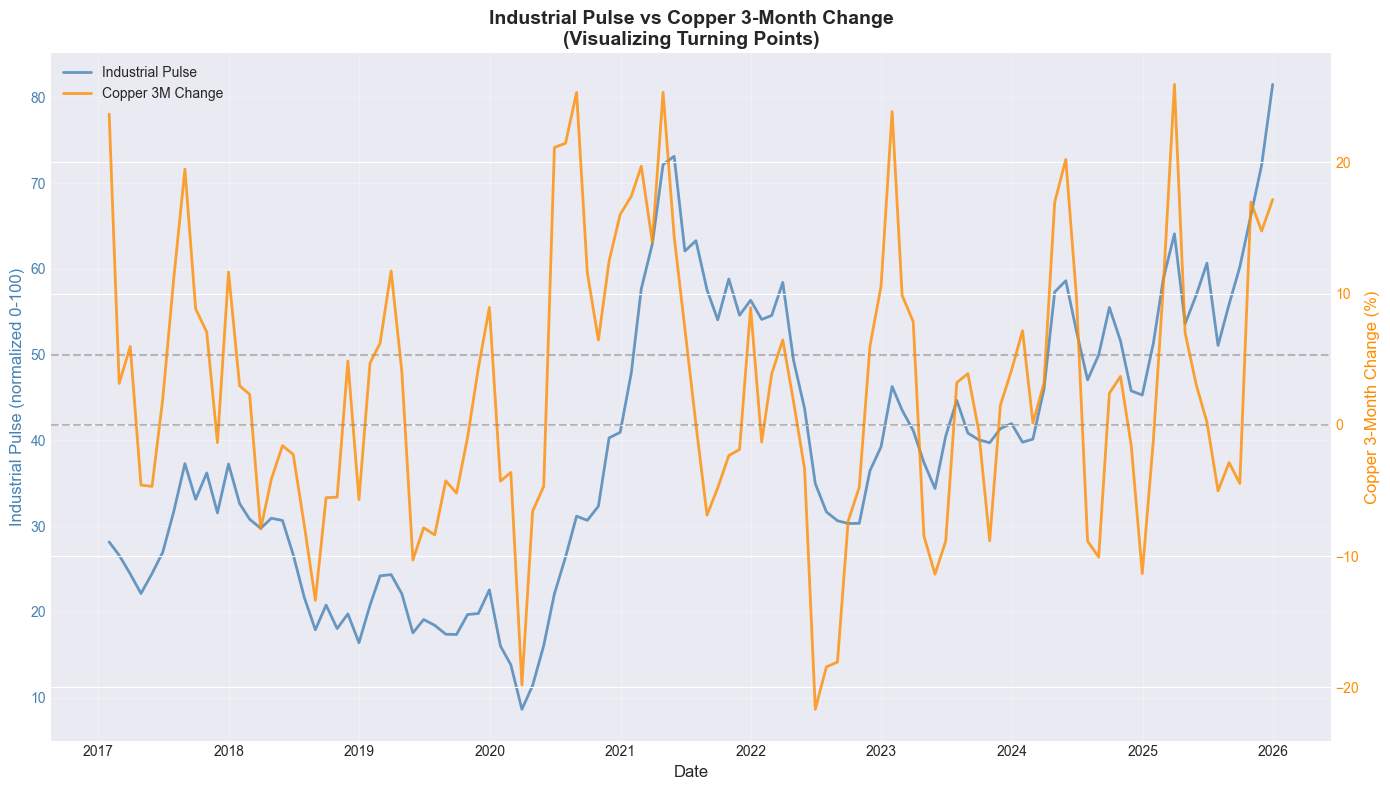

In [39]:
# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot Industrial Pulse on left axis
color1 = 'steelblue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Industrial Pulse (normalized 0-100)', color=color1, fontsize=12)
line1 = ax1.plot(all_data.index, all_data['Industrial_Pulse'], color=color1, 
                 linewidth=2, label='Industrial Pulse', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Pulse Neutral (50)')

# Create second y-axis for Copper 3M Change
ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.set_ylabel('Copper 3-Month Change (%)', color=color2, fontsize=12)
line2 = ax2.plot(all_data.index, all_data['Copper_3M_Change'], color=color2, 
                 linewidth=2, label='Copper 3M Change', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

plt.title('Industrial Pulse vs Copper 3-Month Change\n(Visualizing Turning Points)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Analyze Lead-Lag Relationship

Check if rises in copper are followed by rises in the pulse within 1-3 months.

In [40]:

copper_rise = all_data['Copper_3M_Change'] > 0

#
pulse_change_1m = all_data['Industrial_Pulse'].pct_change(1).shift(-1) * 100  # 1 month ahead
pulse_change_2m = all_data['Industrial_Pulse'].pct_change(2).shift(-2) * 100  # 2 months ahead  
pulse_change_3m = all_data['Industrial_Pulse'].pct_change(3).shift(-3) * 100  # 3 months ahead


pulse_abs_change_1m = all_data['Industrial_Pulse'].diff(1).shift(-1)  # 1 month ahead
pulse_abs_change_2m = all_data['Industrial_Pulse'].diff(2).shift(-2)  # 2 months ahead
pulse_abs_change_3m = all_data['Industrial_Pulse'].diff(3).shift(-3)  # 3 months ahead


analysis = pd.DataFrame(index=all_data.index)
analysis['Copper_Rise'] = copper_rise
analysis['Pulse_Rise_1M'] = pulse_abs_change_1m > 0
analysis['Pulse_Rise_2M'] = pulse_abs_change_2m > 0
analysis['Pulse_Rise_3M'] = pulse_abs_change_3m > 0

# Drop NaN values (from shift operations)
analysis = analysis.dropna()

print("Analysis data shape:", analysis.shape)
print("\nFirst 10 rows of analysis:")
print(analysis.head(10))

Analysis data shape: (108, 4)

First 10 rows of analysis:
            Copper_Rise  Pulse_Rise_1M  Pulse_Rise_2M  Pulse_Rise_3M
Date                                                                
2017-01-31         True          False          False          False
2017-02-28         True          False          False          False
2017-03-31         True          False           True           True
2017-04-30        False           True           True           True
2017-05-31        False           True           True           True
2017-06-30         True           True           True           True
2017-07-31         True           True           True           True
2017-08-31         True          False          False          False
2017-09-30         True           True          False           True
2017-10-31         True          False           True          False


In [41]:

copper_rise_episodes = analysis[analysis['Copper_Rise'] == True]

if len(copper_rise_episodes) > 0:

    episodes_1m = (copper_rise_episodes['Pulse_Rise_1M'] == True).sum()
    episodes_2m = (copper_rise_episodes['Pulse_Rise_2M'] == True).sum()
    episodes_3m = (copper_rise_episodes['Pulse_Rise_3M'] == True).sum()
    
    total_episodes = len(copper_rise_episodes)
    
    share_1m = episodes_1m / total_episodes * 100
    share_2m = episodes_2m / total_episodes * 100
    share_3m = episodes_3m / total_episodes * 100
    
    pulse_rise_within_3m = (copper_rise_episodes['Pulse_Rise_1M'] | 
                            copper_rise_episodes['Pulse_Rise_2M'] | 
                            copper_rise_episodes['Pulse_Rise_3M'])
    share_within_3m = pulse_rise_within_3m.sum() / total_episodes * 100
    
    print("=" * 60)
    print("LEAD-LAG ANALYSIS: Copper Rises → Industrial Pulse Rises")
    print("=" * 60)
    print(f"\nTotal copper rise episodes: {total_episodes}")
    print(f"\nFollowed by pulse rise within:")
    print(f"  1 month:  {episodes_1m:3d} episodes ({share_1m:.1f}%)")
    print(f"  2 months: {episodes_2m:3d} episodes ({share_2m:.1f}%)")
    print(f"  3 months: {episodes_3m:3d} episodes ({share_3m:.1f}%)")
    print(f"\nWithin 1-3 months (any): {pulse_rise_within_3m.sum():3d} episodes ({share_within_3m:.1f}%)")
    print("=" * 60)
else:
    print("No copper rise episodes found in the sample")

LEAD-LAG ANALYSIS: Copper Rises → Industrial Pulse Rises

Total copper rise episodes: 61

Followed by pulse rise within:
  1 month:   30 episodes (49.2%)
  2 months:  24 episodes (39.3%)
  3 months:  24 episodes (39.3%)

Within 1-3 months (any):  39 episodes (63.9%)


In [42]:

print("\nSUMMARY STATISTICS")
print("=" * 60)
print(f"Sample period: {all_data.index.min().strftime('%Y-%m')} to {all_data.index.max().strftime('%Y-%m')}")
print(f"Total months: {len(all_data)}")
print(f"\nIndustrial Pulse:")
print(f"  Mean: {all_data['Industrial_Pulse'].mean():.2f}")
print(f"  Std:  {all_data['Industrial_Pulse'].std():.2f}")
print(f"  Min:  {all_data['Industrial_Pulse'].min():.2f}")
print(f"  Max:  {all_data['Industrial_Pulse'].max():.2f}")
print(f"\nCopper 3M Change:")
print(f"  Mean: {all_data['Copper_3M_Change'].mean():.2f}%")
print(f"  Std:  {all_data['Copper_3M_Change'].std():.2f}%")


SUMMARY STATISTICS
Sample period: 2017-01 to 2025-12
Total months: 108

Industrial Pulse:
  Mean: 39.06
  Std:  16.21
  Min:  8.64
  Max:  81.52

Copper 3M Change:
  Mean: 2.71%
  Std:  10.46%
